In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# -----------------------------
# Load data
# -----------------------------
# load dataset
df = pd.read_csv("Master Data(06022026).csv")

# -----------------------------
# Define variable groups
# -----------------------------
flood_vars = [
    "% of catchment in flood-risk zone",
    "Road flood days per year",
    "% of road length flooded at least once",
    "Max flood duration"
]

infra_vars = [
    "Catchment area km2",
    "Total road length in catchment",
    "% of minor roads",
    "Avg elevation"
]

# -----------------------------
# Robust PCA function
# -----------------------------
def run_pca(df, variables, prefix, impute_strategy="mean"):

    # Subset variables
    X = df[variables].copy()

    # Force numeric (coerce junk like 'NA', '<5', etc. to NaN)
    X = X.apply(pd.to_numeric, errors="coerce")

    # Replace infinities with NaN
    X = X.replace([np.inf, -np.inf], np.nan)

    # Drop columns that are entirely NaN
    X = X.dropna(axis=1, how="all")

    # Drop zero-variance columns
    X = X.loc[:, X.std() > 0]

    # -----------------------------
    # IMPUTATION STEP (UPDATED)
    # -----------------------------
    if impute_strategy == "zero":
        # Assume missing = no event
        X = X.fillna(0)

    elif impute_strategy == "mean":
        # Standard PCA approach
        X = X.fillna(X.mean())

    else:
        raise ValueError("impute_strategy must be 'zero' or 'mean'")

    # -----------------------------
    # Standardise
    # -----------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -----------------------------
    # PCA
    # -----------------------------
    pca = PCA()
    X_pca = pca.fit_transform(X_scaled)

    # PCA scores
    pca_df = pd.DataFrame(
        X_pca,
        columns=[f"{prefix}_PC{i+1}" for i in range(X_pca.shape[1])],
        index=df.index
    )

    # PCA loadings
    loadings = pd.DataFrame(
        pca.components_.T,
        index=X.columns,
        columns=pca_df.columns
    )

    return pca_df, pca, loadings


# -----------------------------
# Run Flood PCA
# -----------------------------
flood_pca_df, flood_pca, flood_loadings = run_pca(
    df,
    flood_vars,
    prefix="Flood"
)

print("Flood PCA explained variance:")
for i, v in enumerate(flood_pca.explained_variance_ratio_):
    print(f"PC{i+1}: {v:.3f}")

# -----------------------------
# Run Infrastructure PCA
# -----------------------------
infra_pca_df, infra_pca, infra_loadings = run_pca(
    df,
    infra_vars,
    prefix="Infra"
)

print("\nInfrastructure PCA explained variance:")
for i, v in enumerate(infra_pca.explained_variance_ratio_):
    print(f"PC{i+1}: {v:.3f}")

# -----------------------------
# Merge PCA scores back to master data
# -----------------------------
df_pca = pd.concat([df, flood_pca_df, infra_pca_df], axis=1)

# -----------------------------
# Save outputs
# -----------------------------
df_pca.to_csv("Master_Data_with_PCA.csv", index=False)
flood_loadings.to_csv("Flood_PCA_Loadings.csv")
infra_loadings.to_csv("Infrastructure_PCA_Loadings.csv")



Flood PCA explained variance:
PC1: 0.432
PC2: 0.333
PC3: 0.234

Infrastructure PCA explained variance:
PC1: 0.648
PC2: 0.232
PC3: 0.120


In [8]:
# ============================================================
# SVM (SVR) MODEL: FLOODING → ATTAINMENT
# ============================================================

import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absoulte_percentage_error

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("Master_Data_with_PCA.csv")

# -----------------------------
# Clean attainment %
# -----------------------------
df["Attainment score"] = (
    df["Attainment score"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

df["Attainment score"] = pd.to_numeric(
    df["Attainment score"],
    errors="coerce"
)

# -----------------------------
# Fill missing flooding PCA = 0
# (your assumption: no flooding)
# -----------------------------
df["Flood_PC1"] = df["Flood_PC1"].fillna(0)
df["Flood_PC2"] = df["Flood_PC2"].fillna(0)

# -----------------------------
# Select variables
# -----------------------------
model_df = df[[
    "Attainment score",
    "Flood_PC1", "Flood_PC2",
    "Infra_PC1", "Infra_PC2", "Infra_PC3",
    "School population"
]].dropna()

print("Sample size:", len(model_df))

# -----------------------------
# Define X and y
# -----------------------------
X = model_df.drop(columns="Attainment score")
y = model_df["Attainment score"]

# -----------------------------
# Train / test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Pipeline: Scaling + SVR
# -----------------------------
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))  # nonlinear kernel
])

# -----------------------------
# Fit model
# -----------------------------
svm_model.fit(X_train, y_train)

# -----------------------------
# Predictions
# -----------------------------
y_pred = svm_model.predict(X_test)

# -----------------------------
# Evaluation
# -----------------------------
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nSVM Performance:")
print("RMSE:", rmse)
print("MAPE", mape)
print("R²:", r2)


ImportError: cannot import name 'mean_absoulte_percentage_error' from 'sklearn.metrics' (C:\Users\bedep\Anaconda\envs\phaseb\Lib\site-packages\sklearn\metrics\__init__.py)

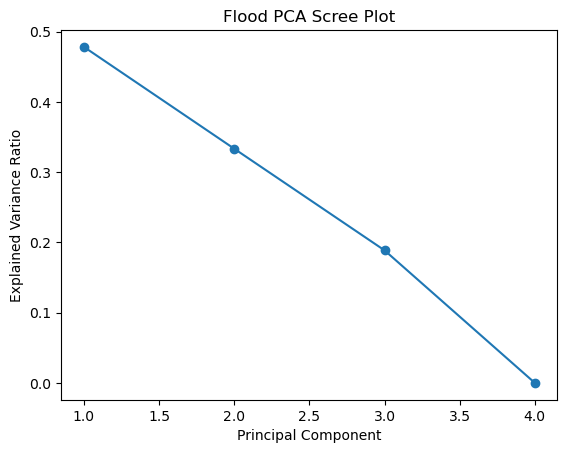

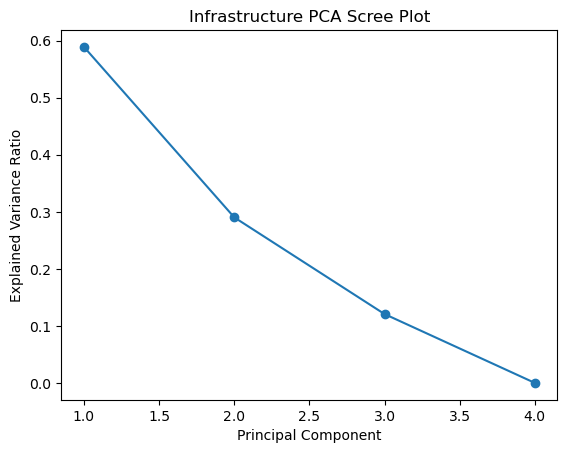

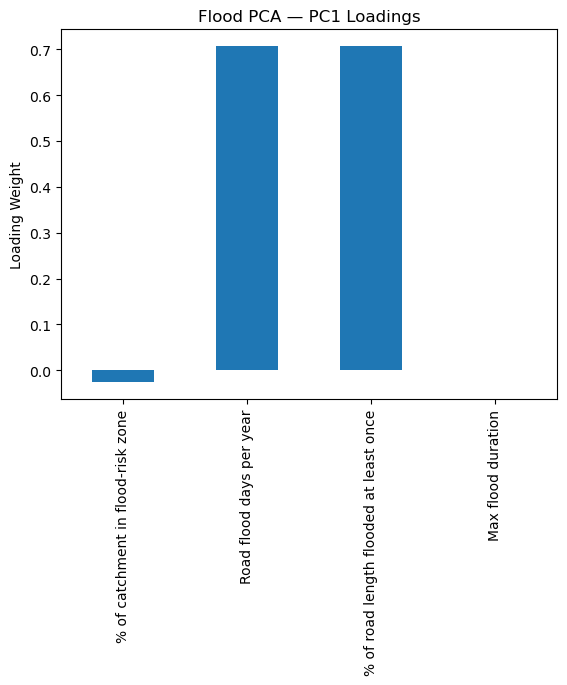

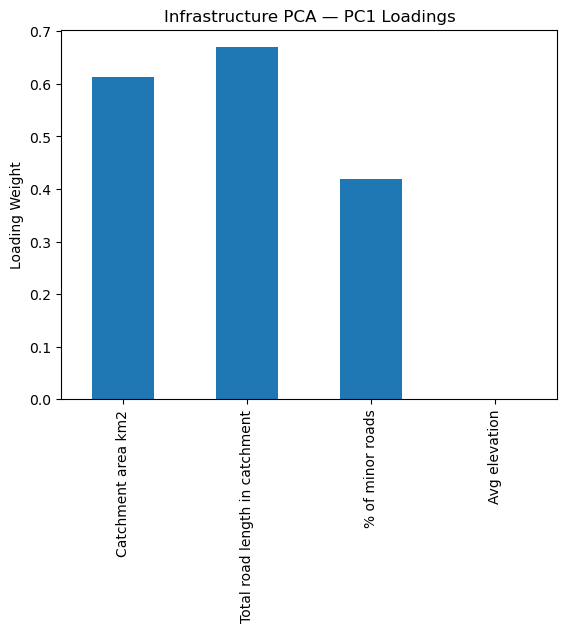

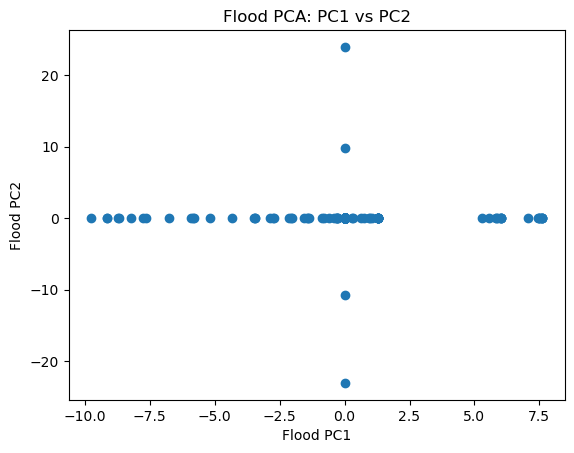

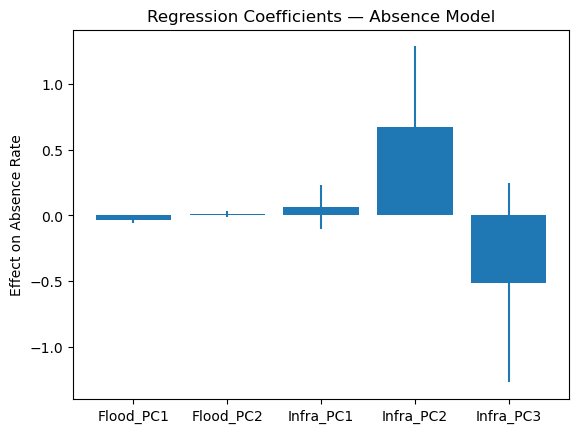

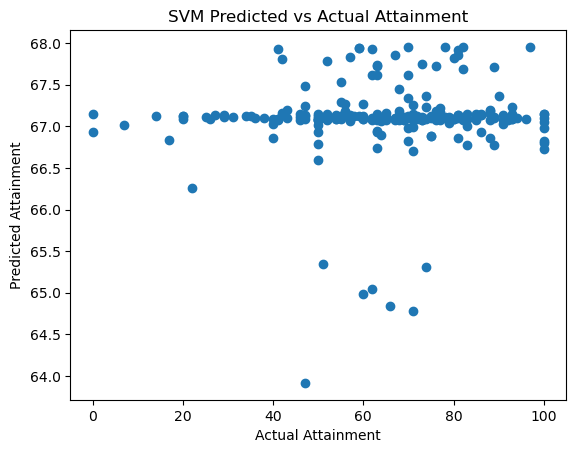

SVM RMSE: 20.206923526110003
SVM R²: -0.008151520207153373


In [6]:
# ============================================================
# PCA + REGRESSION + SVM VISUALISATIONS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("Master_Data_with_PCA.csv")

# Clean attainment %
df["Attainment score"] = (
    df["Attainment score"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)
df["Attainment score"] = pd.to_numeric(df["Attainment score"], errors="coerce")

# ============================================================
# 1️⃣ SCREE PLOTS
# ============================================================

flood_vars = [
    "% of catchment in flood-risk zone",
    "Road flood days per year",
    "% of road length flooded at least once",
    "Max flood duration"
]

infra_vars = [
    "Catchment area km2",
    "Total road length in catchment",
    "% of minor roads",
    "Avg elevation"
]

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def scree_plot(data, vars_list, title):

    X = data[vars_list].apply(pd.to_numeric, errors="coerce").fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA()
    pca.fit(X_scaled)

    plt.figure()
    plt.plot(
        range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
        marker="o"
    )
    plt.title(title)
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance Ratio")
    plt.show()

# Flood scree
scree_plot(df, flood_vars, "Flood PCA Scree Plot")

# Infrastructure scree
scree_plot(df, infra_vars, "Infrastructure PCA Scree Plot")


# ============================================================
# 2️⃣ PCA LOADING BAR CHARTS
# ============================================================

def loading_plot(data, vars_list, title):

    X = data[vars_list].apply(pd.to_numeric, errors="coerce").fillna(0)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA()
    pca.fit(X_scaled)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=vars_list,
        columns=[f"PC{i+1}" for i in range(len(vars_list))]
    )

    loadings["PC1"].plot(kind="bar")
    plt.title(title + " — PC1 Loadings")
    plt.ylabel("Loading Weight")
    plt.show()

# Flood loadings
loading_plot(df, flood_vars, "Flood PCA")

# Infrastructure loadings
loading_plot(df, infra_vars, "Infrastructure PCA")


# ============================================================
# 3️⃣ PC1 vs PC2 SCATTER
# ============================================================

plt.figure()

plt.scatter(
    df["Flood_PC1"],
    df["Flood_PC2"]
)

plt.title("Flood PCA: PC1 vs PC2")
plt.xlabel("Flood PC1")
plt.ylabel("Flood PC2")
plt.show()


# ============================================================
# 4️⃣ REGRESSION COEFFICIENT PLOT (ABSENCE)
# ============================================================

df_abs = df[[
    "Absence rate",
    "Flood_PC1", "Flood_PC2",
    "Infra_PC1", "Infra_PC2", "Infra_PC3",
    "School population",
    "Year",
    "School URN"
]].dropna()

model = smf.ols(
    formula="""
    Q("Absence rate") ~ 
    Flood_PC1 + Flood_PC2 +
    Infra_PC1 + Infra_PC2 + Infra_PC3 +
    Q("School population") +
    C(Year) +
    C(Q("School URN"))
    """,
    data=df_abs
).fit()

coefs = model.params
errors = model.bse

coef_df = pd.DataFrame({
    "coef": coefs,
    "err": errors
})

coef_df = coef_df.loc[
    ["Flood_PC1", "Flood_PC2",
     "Infra_PC1", "Infra_PC2", "Infra_PC3"]
]

plt.figure()

plt.bar(coef_df.index, coef_df["coef"])
plt.errorbar(
    coef_df.index,
    coef_df["coef"],
    yerr=coef_df["err"],
    fmt="none"
)

plt.title("Regression Coefficients — Absence Model")
plt.ylabel("Effect on Absence Rate")
plt.show()


# ============================================================
# 5️⃣ PREDICTED vs ACTUAL (SVM ATTAINMENT)
# ============================================================

df_svm = df[[
    "Attainment score",
    "Flood_PC1", "Flood_PC2",
    "Infra_PC1", "Infra_PC2", "Infra_PC3",
    "School population"
]].dropna()

X = df_svm.drop(columns=["Attainment score"])
y = df_svm["Attainment score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

svm_model = SVR(kernel="rbf")
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)

plt.figure()

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Attainment")
plt.ylabel("Predicted Attainment")
plt.title("SVM Predicted vs Actual Attainment")
plt.show()

# Performance metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("SVM RMSE:", rmse)
print("SVM R²:", r2)
